# Graphing and Zoom Inset Demonstrations

This notebook showcases the full capabilities of the `lab_math_tools.graphing` module:
- **`plot_measurements`**: 2D plotting of single or multi-series experimental and numerical data, supporting gradient, colormap, and specific coloring modes, custom markers/linestyles, independent X grids, and layered plot composition.
- **`add_zoom_inset`**: Adding focused zoomed-in subplots (insets) to existing plots with preset or custom placement, automatic grid mirroring, configurable indicator boxes, and smart connector lines.


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from lab_math_tools.graphing import (
    plot_measurements,
    add_zoom_inset,
)


---
## 1. `plot_measurements` Demonstrations

### 1.1 Basic Multi-Series Plot
Plotting multiple mathematical curves against a shared X domain, with custom labels, linestyles, markers, and grid lines.


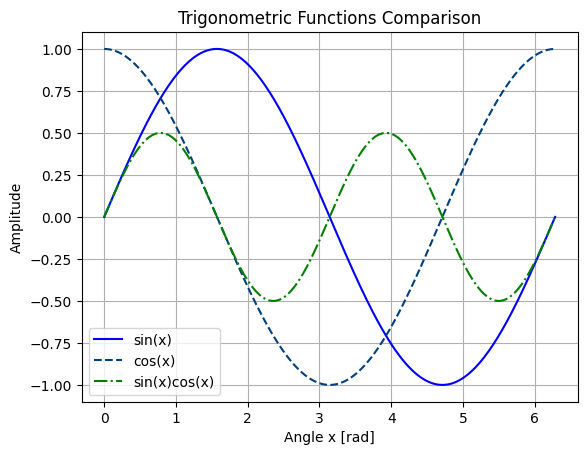

In [2]:
# Define a shared x-domain vector
v_x = np.linspace(0, 2 * np.pi, 300)

# Generate measurement series
v_y1 = np.sin(v_x)
v_y2 = np.cos(v_x)
v_y3 = np.sin(v_x) * np.cos(v_x)

# Plot with custom linestyles and labels
plot_measurements(
    lv_x=v_x,
    lv_y=[v_y1, v_y2, v_y3],
    line_labels=["sin(x)", "cos(x)", "sin(x)cos(x)"],
    linestyles=["-", "--", "-."],
    markers=["", "", ""],
    title="Trigonometric Functions Comparison",
    x_label="Angle x [rad]",
    y_label="Amplitude",
    grid=True,
    show=False,
)


### 1.2 Color Methods: Gradient, Colormap, and Specific
`plot_measurements` provides three distinct ways to style measurement series:
- **`"gradient"`**: Smooth color interpolation between two end colors across all series.
- **`"colormap"`**: Samples colors evenly from any Matplotlib colormap name.
- **`"specific"`**: Explicit list of colors mapped 1-to-1 to each measurement line.


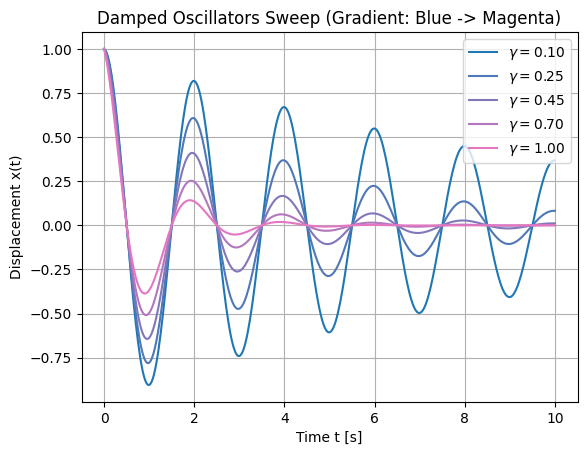

In [3]:
# Damped harmonic oscillators with varying damping coefficients
v_t = np.linspace(0, 10, 400)
l_gammas = [0.1, 0.25, 0.45, 0.7, 1.0]
lv_y_damped = [np.exp(-gamma * v_t) * np.cos(2 * np.pi * 0.5 * v_t) for gamma in l_gammas]
line_labels = [rf"$\gamma = {gamma:.2f}$" for gamma in l_gammas]

# Gradient from deep blue to bright magenta
plot_measurements(
    lv_x=v_t,
    lv_y=lv_y_damped,
    line_labels=line_labels,
    color_method="gradient",
    colors=["#1f77b4", "#e377c2"],
    markers="",
    title="Damped Oscillators Sweep (Gradient: Blue -> Magenta)",
    x_label="Time t [s]",
    y_label="Displacement x(t)",
    grid=True,
    show=False,
)


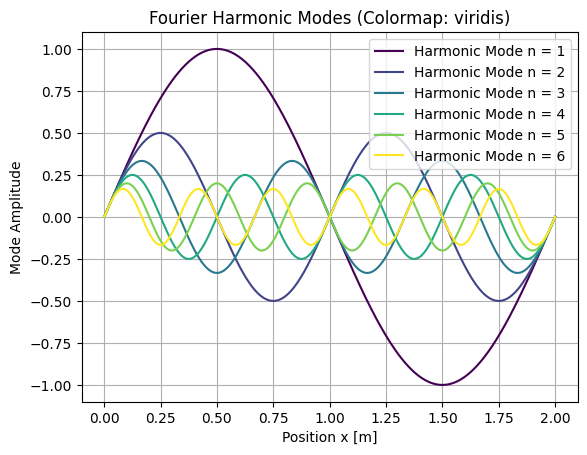

In [4]:
# Fourier harmonic modes
v_x_harm = np.linspace(0, 2, 400)
l_modes = [1, 2, 3, 4, 5, 6]
lv_y_modes = [np.sin(n * np.pi * v_x_harm) / n for n in l_modes]
line_labels_modes = [f"Harmonic Mode n = {n}" for n in l_modes]

# Sample colors from the "viridis" colormap
plot_measurements(
    lv_x=v_x_harm,
    lv_y=lv_y_modes,
    line_labels=line_labels_modes,
    color_method="colormap",
    colors="viridis",
    markers="",
    title="Fourier Harmonic Modes (Colormap: viridis)",
    x_label="Position x [m]",
    y_label="Mode Amplitude",
    grid=True,
    show=False,
)


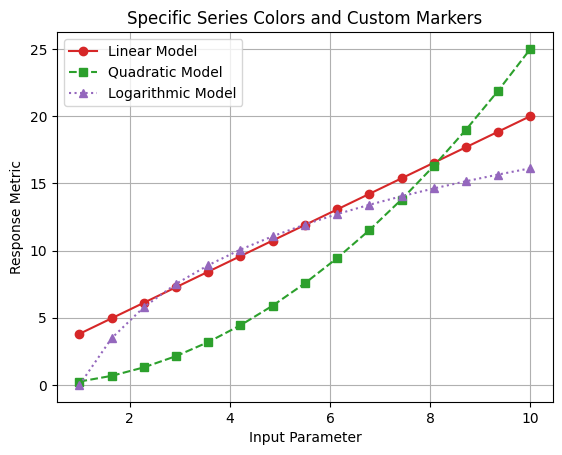

In [5]:
# Discrete models with distinct markers, linestyles, and specific colors
v_x_pts = np.linspace(1, 10, 15)
v_y_linear = 1.8 * v_x_pts + 2.0
v_y_quad = 0.25 * v_x_pts**2
v_y_log = 7.0 * np.log(v_x_pts)

plot_measurements(
    lv_x=v_x_pts,
    lv_y=[v_y_linear, v_y_quad, v_y_log],
    line_labels=["Linear Model", "Quadratic Model", "Logarithmic Model"],
    color_method="specific",
    colors=["#d62728", "#2ca02c", "#9467bd"],
    linestyles=["-", "--", ":"],
    markers=["o", "s", "^"],
    title="Specific Series Colors and Custom Markers",
    x_label="Input Parameter",
    y_label="Response Metric",
    grid=True,
    show=False,
)


### 1.3 Independent X-Grids and Plot Composition
Measurements can have distinct X domains or sampling resolutions by passing a list of vectors `lv_x=[v_x1, v_x2, ...]`.\
Furthermore, passing an existing `ax` allows layering multiple plots onto the same canvas.


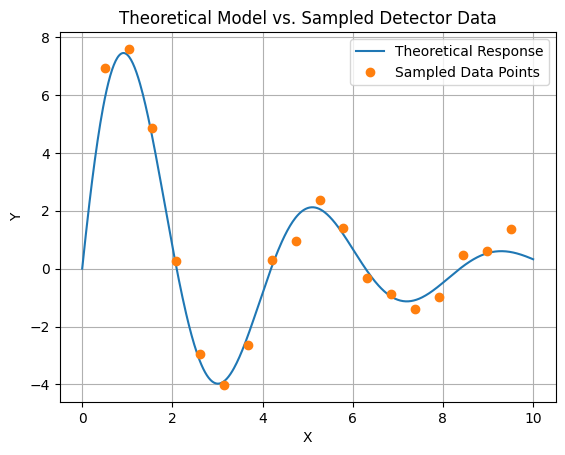

In [6]:
# 1. Theoretical continuous model (high resolution)
v_x_model = np.linspace(0, 10, 500)
v_y_model = 10.0 * np.exp(-0.3 * v_x_model) * np.sin(1.5 * v_x_model)

# Plot continuous baseline
ax = plot_measurements(
    lv_x=v_x_model,
    lv_y=v_y_model,
    line_labels=["Theoretical Response"],
    color_method="specific",
    colors=["#1f77b4"],
    linestyles="-",
    markers="",
    title="Theoretical Model vs. Sampled Detector Data",
    x_label="Time [ms]",
    y_label="Detector Signal [mV]",
    grid=True,
    show=False,
)

# 2. Discrete sparse measurements (low resolution with noise)
np.random.seed(101)
v_x_meas = np.linspace(0.5, 9.5, 18)
v_y_meas = 10.0 * np.exp(-0.3 * v_x_meas) * np.sin(1.5 * v_x_meas) + np.random.normal(0, 0.4, len(v_x_meas))

# Overlay discrete data points onto the existing ax
plot_measurements(
    lv_x=v_x_meas,
    lv_y=v_y_meas,
    line_labels=["Sampled Data Points"],
    color_method="specific",
    colors=["#ff7f0e"],
    linestyles="",
    markers="o",
    ax=ax,
    show=False,
)


---
## 2. `add_zoom_inset` Demonstrations

### 2.1 Basic Zoom and Preset Inset Placement
`add_zoom_inset` creates a magnified view of a region of interest `(x_range, y_range)`.
Positions can be specified using convenient presets: `"upper_right"`, `"upper_left"`, `"upper_middle"`, `"middle_right"`, `"middle_left"`, `"center"`, `"lower_right"`, `"lower_left"`, `"lower_middle"`.


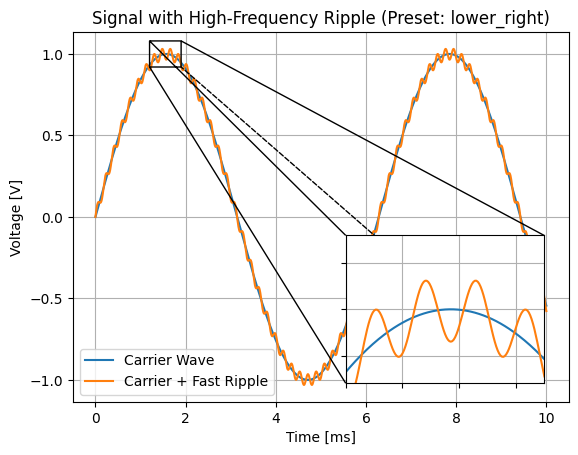

In [7]:
# High-frequency modulated wave
v_x_sig = np.linspace(0, 10, 2000)
v_y_base = np.sin(v_x_sig)
v_y_ripple = v_y_base + 0.035 * np.sin(35 * v_x_sig)

# Base plot
ax = plot_measurements(
    lv_x=v_x_sig,
    lv_y=[v_y_base, v_y_ripple],
    line_labels=["Carrier Wave", "Carrier + Fast Ripple"],
    color_method="specific",
    colors=["#1f77b4", "#ff7f0e"],
    markers="",
    title="Signal with High-Frequency Ripple (Preset: lower_right)",
    x_label="Time [ms]",
    y_label="Voltage [V]",
    grid=True,
    show=False,
)

# Zoom in on the primary peak using preset "lower_right"
add_zoom_inset(
    ax=ax,
    x_range=(1.2, 1.9),
    y_range=(0.92, 1.08),
    inset_bounds="lower_right",
    show=False,
)


### 2.2 Custom Inset Geometry and Axis Coordinate Readout
You can specify custom normalized bounds `(x0, y0, width, height)` and enable tick labels via `zoom_labels=True` for numerical inspection.


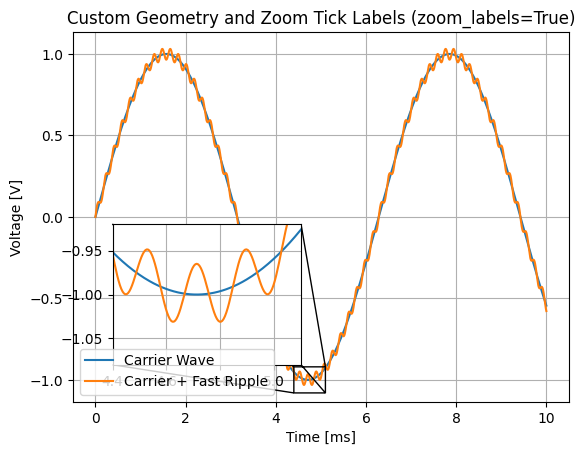

In [8]:
# Base plot
ax = plot_measurements(
    lv_x=v_x_sig,
    lv_y=[v_y_base, v_y_ripple],
    line_labels=["Carrier Wave", "Carrier + Fast Ripple"],
    color_method="specific",
    colors=["#1f77b4", "#ff7f0e"],
    markers="",
    title="Custom Geometry and Zoom Tick Labels (zoom_labels=True)",
    x_label="Time [ms]",
    y_label="Voltage [V]",
    grid=True,
    show=False,
)

# Inset placed at custom normalized coordinates with tick labels enabled
add_zoom_inset(
    ax=ax,
    x_range=(4.4, 5.1),
    y_range=(-1.08, -0.92),
    inset_bounds=(0.08, 0.10, 0.38, 0.38),
    zoom_labels=True,
    show=False,
)


### 2.3 Indicator Styling and Smart Connectors
The `indicator_settings` dictionary allows full control over the zoom indicator box and connector lines:
- `edgecolor`: Color of rectangle border and connector lines.
- `linewidth`: Width of border and connectors.
- `linestyle`: Style of outer connectors (`"-"`, `"--"`, `":"`, etc.).
- `alpha`: Opacity of the indicators.

*Note: Connectors that pass behind the inset box are automatically drawn as dashed lines (`"--"`) to maintain visual clarity without obstruction.*


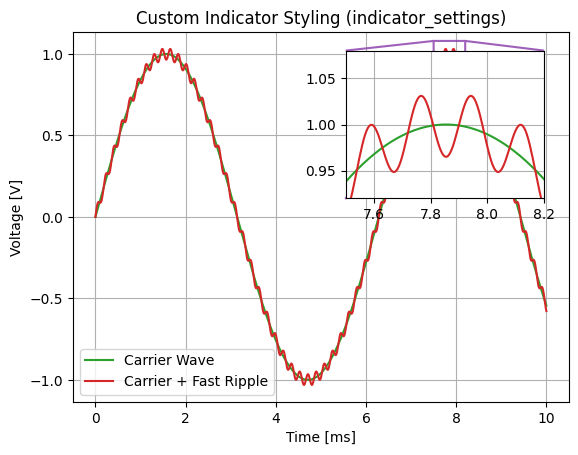

In [9]:
ax = plot_measurements(
    lv_x=v_x_sig,
    lv_y=[v_y_base, v_y_ripple],
    line_labels=["Carrier Wave", "Carrier + Fast Ripple"],
    color_method="specific",
    colors=["#2ca02c", "#d62728"],
    markers="",
    title="Custom Indicator Styling (indicator_settings)",
    x_label="Time [ms]",
    y_label="Voltage [V]",
    grid=True,
    show=False,
)

indicator_settings = {
    "edgecolor": "#8e44ad",
    "linewidth": 1.5,
    "linestyle": "-",
    "alpha": 0.85,
}

add_zoom_inset(
    ax=ax,
    x_range=(7.5, 8.2),
    y_range=(0.92, 1.08),
    inset_bounds="upper_right",
    zoom_labels=True,
    indicator_settings=indicator_settings,
    show=False,
)


### 2.4 Multiple Zoom Insets on a Single Plot
You can attach multiple zoom insets to the same plot to simultaneously inspect multiple regions of interest (e.g., a peak and a trough).


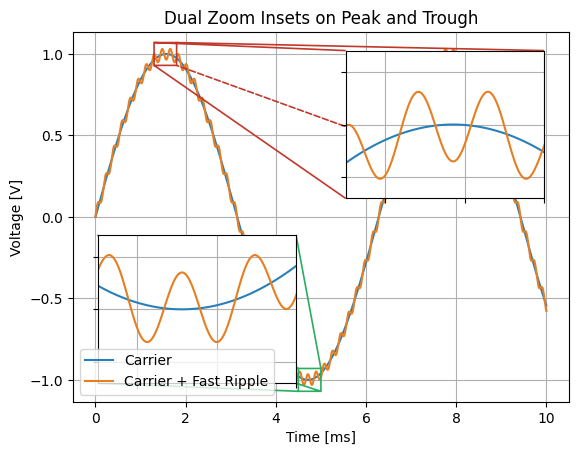

In [10]:
ax = plot_measurements(
    lv_x=v_x_sig,
    lv_y=[v_y_base, v_y_ripple],
    line_labels=["Carrier", "Carrier + Fast Ripple"],
    color_method="specific",
    colors=["#2980b9", "#e67e22"],
    markers="",
    title="Dual Zoom Insets on Peak and Trough",
    x_label="Time [ms]",
    y_label="Voltage [V]",
    grid=True,
    show=False,
)

# Inset 1: Zooming into positive peak at upper right
add_zoom_inset(
    ax=ax,
    x_range=(1.3, 1.8),
    y_range=(0.93, 1.07),
    inset_bounds="upper_right",
    zoom_labels=False,
    indicator_settings={"edgecolor": "#c0392b", "linewidth": 1.2},
    show=False,
)

# Inset 2: Zooming into negative trough at lower left
add_zoom_inset(
    ax=ax,
    x_range=(4.5, 5.0),
    y_range=(-1.07, -0.93),
    inset_bounds="lower_left",
    zoom_labels=False,
    indicator_settings={"edgecolor": "#27ae60", "linewidth": 1.2},
    show=False,
)


---
## 3. Advanced Real-World Lab Example: Resonance Peak Analysis

In this comprehensive demonstration, we model a particle/nuclear scattering experiment measuring a differential cross-section $\sigma(E)$ featuring:
1. A smooth non-resonant continuum background $\sigma_{\text{bg}}(E) = \frac{A}{E + B}$.
2. A narrow Breit-Wigner / Lorentzian resonance peak $\sigma_{\text{res}}(E) = \frac{\sigma_0}{\pi} \frac{\Gamma/2}{(E - E_0)^2 + (\Gamma/2)^2}$.
3. Simulated experimental measurements with statistical noise.
4. Seamless zoom inset focusing directly on the resonance peak with matched grid, custom indicators, and coordinate axes.


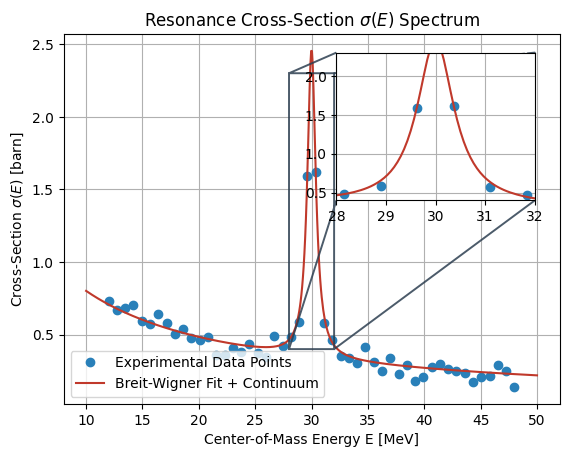

In [11]:
# 1. Energy domain [MeV]
v_energy_dense = np.linspace(10.0, 50.0, 600)
v_e0 = 30.0     # Resonance center [MeV]
v_gamma = 0.9   # Full width at half maximum (FWHM) [MeV]

# Theoretical continuum + Breit-Wigner resonance
v_bg_dense = 12.0 / (v_energy_dense + 5.0)
v_res_dense = (3.0 / np.pi) * ((v_gamma / 2.0) / ((v_energy_dense - v_e0)**2 + (v_gamma / 2.0)**2))
v_theory_cross_sec = v_bg_dense + v_res_dense

# 2. Simulated experimental data points with statistical noise
np.random.seed(42)
v_energy_exp = np.linspace(12.0, 48.0, 50)
v_bg_exp = 12.0 / (v_energy_exp + 5.0)
v_res_exp = (3.0 / np.pi) * ((v_gamma / 2.0) / ((v_energy_exp - v_e0)**2 + (v_gamma / 2.0)**2))
v_meas_cross_sec = v_bg_exp + v_res_exp + np.random.normal(0, 0.05, len(v_energy_exp))

# 3. Plot experimental points and theoretical fit curve
ax = plot_measurements(
    lv_x=[v_energy_exp, v_energy_dense],
    lv_y=[v_meas_cross_sec, v_theory_cross_sec],
    line_labels=["Experimental Data Points", "Breit-Wigner Fit + Continuum"],
    color_method="specific",
    colors=["#2980b9", "#c0392b"],
    linestyles=["", "-"],
    markers=["o", ""],
    title=r"Resonance Cross-Section $\sigma(E)$ Spectrum",
    x_label="Center-of-Mass Energy E [MeV]",
    y_label=r"Cross-Section $\sigma(E)$ [barn]",
    grid=True,
    show=False,
)

# 4. Add zoomed inset panel focusing on the narrow resonance peak
indicator_settings = {
    "edgecolor": "#2c3e50",
    "linewidth": 1.4,
    "linestyle": "-",
    "alpha": 0.85,
}

add_zoom_inset(
    ax=ax,
    x_range=(28.0, 32.0),
    y_range=(0.4, 2.3),
    inset_bounds="upper_right",
    zoom_labels=True,
    indicator_settings=indicator_settings,
    show=False,
)
